# INSTRUCTION FINE-TUNING OF GPT-2(355M) WITH A SET OF INSTRUCTION,INPUT & RESPONSE DATASET

### Step 01: PREPARING DATASET

#### IMPORTING DATASET

In [ ]:
!pip install tiktoken
import tiktoken
import torch
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Chosen Device: ", device)

Chosen Device:  cuda


In [ ]:
# Let's load the dataset which consists of 1100 "Instruction-Input-Output" pairs
import json

with open("/content/drive/MyDrive/GEN AI (LLMs)/Instruction-Based Fine-Tuning/instruction-data.json", 'r') as file:
  data = json.load(file)

print("Number of Enteries in data:",len(data))

Number of Enteries in data: 1100


In [ ]:
print(data[50])

{'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [ ]:
data[999]

{'instruction': "What is an antonym of 'complicated'?",
 'input': '',
 'output': "An antonym of 'complicated' is 'simple'."}

#### CONVERTING INSTRUCTIONS INTO ALPACA FORMAT

In [ ]:
def format_input(entry):
  instruction_text = (
      f"Below is an instruction that describes a task. "
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['instruction']}"
  )

  input_text = f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""

  return instruction_text + input_text

In [ ]:
# Let's test above created function
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [ ]:
# Let's test above created function
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [ ]:
int(len(data) * 0.85)

935

#### SPLITTING DATASET INTO TRAIN-TEST-VALIDATION

In [ ]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)  # 10% for testing
val_portion = len(data) - train_portion - test_portion   # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[test_portion + train_portion:]

print("Training data length: ",len(train_data))
print(f"Testing data length: {len(test_data)}")
print(f"Validation Data length: {len(val_data)}")

Training data length:  935
Testing data length: 110
Validation Data length: 55


### Step 02: ORGANIZE DATA IN TRAINING,TESTING,VALIDATING BATCHES

    Steps to be followed:
    1. Format data using prompt template
    2. Tokenize formatted data
    3. Adjust to the same length with padding tokens
    4. Create target token IDs for training
    5. Replace padding tokens with placeholders eg.(-100, {Adding ignoring index}, -100 because we need to not consider these extra tokens while calculating LOSS function and while calling our LOSS function we can define ignorances of tokens with value (-100).

In [ ]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
  def __init__(self,data,tokenizer):
    self.data = data

    # Pre-tokenize texts
    self.encoded_texts = []
    for entry in data:
      instruction_plus_input = format_input(entry)
      response_text = f"\n\n### Response:\n{entry['output']}"
      full_text = instruction_plus_input + response_text
      self.encoded_texts.append(tokenizer.encode(full_text))

  def __getitem__(self,index):
    return self.encoded_texts[index]

  def __len__(self):
    return len(self.data)


In [ ]:
# Now Let's define a function which will add the "<|endoftext|>:50256" token as a padding to each encoded input to have same length of all inputs in batch
# Function for preparing Input token IDs
def custom_collate_draft_1(batch,pad_token_id = 50256):   # Can add device here also

  # Find the longest sequence in the batch and increase the max length by +1, which will add one extra padding token below
  batch_max_length = max(len(item) + 1 for item in batch)

  # Pad and prepare inputs
  inputs_lst = []

  for item in batch:
    new_item = item.copy()
    new_item +=[pad_token_id]   # Adding padding token to each and every item
    # Pad sequences to batch_max_length
    padded = (
        new_item + [pad_token_id] * (batch_max_length - len(new_item))
    )

    inputs = torch.tensor(padded[:-1])   # here we are removing extra padded token
    inputs_lst.append(inputs)

  # Convert list of inputs to tensor and transfer to target device
  inputs_tensor = torch.stack(inputs_lst)
  return inputs_tensor

In [ ]:
# Let's see an example of using above defined function
l1 = [0,1,2,3,4,5]
l2 = [4,5,6]
l3 = [7,8,9,0]

batch = (l1,l2,l3)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4,     5],
        [    4,     5,     6, 50256, 50256, 50256],
        [    7,     8,     9,     0, 50256, 50256]])


In [ ]:
# Now Let's define a function which will add the "<|endoftext|>:50256" token as a padding to each encoded input
# Function for preparing input & target token IDs
def custom_collate_draft_2(batch,pad_token_id = 50256):   # Can add device here also

  # Find the longest sequence in the batch and increase the max length by +1, which will add one extra padding token below
  batch_max_length = max(len(item) + 1 for item in batch)

  # Pad and prepare inputs
  inputs_lst , target_lst = [], []

  for item in batch:
    new_item = item.copy()
    new_item +=[pad_token_id]   # Adding padding token to each and every item
    # Pad sequences to batch_max_length
    padded = (
        new_item + [pad_token_id] * (batch_max_length - len(new_item))
    )

    inputs = torch.tensor(padded[:-1])   # here we are removing extra padded token
    targets = torch.tensor(padded[1:])   # Shift + 1 to the right for targets
    inputs_lst.append(inputs)
    target_lst.append(targets)

  # Convert list of inputs to tensor and transfer to target device
  inputs_tensor = torch.stack(inputs_lst)
  targets_tensor = torch.stack(target_lst)

  return inputs_tensor,targets_tensor

In [ ]:
# Let's see an example of using above defined function
l1 = [0,1,2,3,4,5]
l2 = [4,5,6]
l3 = [7,8,9,0]

batch = (l1,l2,l3)
input, target = custom_collate_draft_2(batch)
print("Input: \n",input)
print("Target: \n",target)

Input: 
 tensor([[    0,     1,     2,     3,     4,     5],
        [    4,     5,     6, 50256, 50256, 50256],
        [    7,     8,     9,     0, 50256, 50256]])
Target: 
 tensor([[    1,     2,     3,     4,     5, 50256],
        [    5,     6, 50256, 50256, 50256, 50256],
        [    8,     9,     0, 50256, 50256, 50256]])


In [ ]:
# Now Let's define a function which will add the "<|endoftext|>:50256" token as a padding to each encoded input
# Function for preparing input & target token IDs while setting ignoring tokens

def custom_collate_fn(batch,pad_token_id = 50256, ignore_index = -100, allowed_max_length = None,device = 'cuda'):   # Can add device here also

  # Find the longest sequence in the batch and increase the max length by +1, which will add one extra padding token below
  batch_max_length = max(len(item) + 1 for item in batch)

  # Pad and prepare inputs
  inputs_lst , target_lst = [], []

  for item in batch:
    new_item = item.copy()
    new_item += [pad_token_id]   # Adding padding token to each and every item
    # Pad sequences to batch_max_length
    padded = (
        new_item + [pad_token_id] * (batch_max_length - len(new_item))
    )

    inputs = torch.tensor(padded[:-1])   # here we are removing extra padded token
    targets = torch.tensor(padded[1:])   # Shift + 1 to the right for targets

    # New: Replace all but the first padding tokens in targets by ignore_index
    mask = targets == pad_token_id
    indices = torch.nonzero(mask).squeeze()
    if indices.numel() > 1:
      targets[indices[1:]] = ignore_index

    # New: Optionally truncate to maximum sequence length
    if allowed_max_length is not None:
      inputs = inputs[:allowed_max_length]
      targets = targets[:allowed_max_length]

    inputs_lst.append(inputs)
    target_lst.append(targets)

  # Convert list of inputs to tensor and transfer to target device
  inputs_tensor = torch.stack(inputs_lst).to(device)
  targets_tensor = torch.stack(target_lst).to(device)

  return inputs_tensor,targets_tensor

In [ ]:
# Let's see an example of using above defined function
l1 = [0,1,2,3,4,5]
l2 = [4,5,6]
l3 = [7,8,9,0]

batch = (l1,l2,l3)
input, target = custom_collate_fn(batch)
print("Input: \n",input)
print("Target: \n",target)

Input: 
 tensor([[    0,     1,     2,     3,     4,     5],
        [    4,     5,     6, 50256, 50256, 50256],
        [    7,     8,     9,     0, 50256, 50256]], device='cuda:0')
Target: 
 tensor([[    1,     2,     3,     4,     5, 50256],
        [    5,     6, 50256,  -100,  -100,  -100],
        [    8,     9,     0, 50256,  -100,  -100]], device='cuda:0')


### MASKING TARGET TOKEN IDS
    Researcher: find out that masking "Instruction and Inputs" part while fine-tuning LLM model is not beneficial, although it's open research topic.

#### STEP 03: CREATING DATALOADERS FOR AN INSTRUCTION DATASET

In [ ]:
# Let's define a function which will help us in customizing parameters of "customc_ollate_fn" function
from functools import partial

customized_collate_fn = partial(custom_collate_fn, device = device, allowed_max_length = 1024)

In [ ]:
# Let's make DataLoaders

from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)
# Training DataLoader
train_dataset = InstructionDataset(train_data,tokenizer)
train_dataloader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last = True,
    num_workers = num_workers
    )

# Test DataLoader
test_dataset = InstructionDataset(test_data,tokenizer)
test_dataloader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers = num_workers
    )
# Validation DataLoader
val_dataset = InstructionDataset(val_data,tokenizer)
val_dataloader = DataLoader(
    val_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers = num_workers
    )

In [ ]:
print("Train Data Loader: \n")
for inputs,targets in train_dataloader:
  print(f"Input Tensor Shape: {inputs.shape} || Target Tensor Shape: {targets.shape}")

Train Data Loader: 

Input Tensor Shape: torch.Size([8, 61]) || Target Tensor Shape: torch.Size([8, 61])
Input Tensor Shape: torch.Size([8, 76]) || Target Tensor Shape: torch.Size([8, 76])
Input Tensor Shape: torch.Size([8, 73]) || Target Tensor Shape: torch.Size([8, 73])
Input Tensor Shape: torch.Size([8, 68]) || Target Tensor Shape: torch.Size([8, 68])
Input Tensor Shape: torch.Size([8, 65]) || Target Tensor Shape: torch.Size([8, 65])
Input Tensor Shape: torch.Size([8, 72]) || Target Tensor Shape: torch.Size([8, 72])
Input Tensor Shape: torch.Size([8, 80]) || Target Tensor Shape: torch.Size([8, 80])
Input Tensor Shape: torch.Size([8, 67]) || Target Tensor Shape: torch.Size([8, 67])
Input Tensor Shape: torch.Size([8, 62]) || Target Tensor Shape: torch.Size([8, 62])
Input Tensor Shape: torch.Size([8, 75]) || Target Tensor Shape: torch.Size([8, 75])
Input Tensor Shape: torch.Size([8, 62]) || Target Tensor Shape: torch.Size([8, 62])
Input Tensor Shape: torch.Size([8, 68]) || Target Tenso

In [ ]:
print("Train Data Loader: \n")
i = 0
for inputs,targets in train_dataloader:
  print(f"Input Tensor Shape: {inputs} || \n Target Tensor Shape: {targets}")
  i += 1
  if i > 1:
    print(f"{i} Data Samples Fetched!!")
    break


Train Data Loader: 

Input Tensor Shape: tensor([[21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
           257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
         21017, 46486,    25,   198, 15946,   485,   262,  1613, 20170,  1296,
           286,   262, 15942,   705,  6679,   577,  2637,   198,   198, 21017,
         18261,    25,   198,   464,  1613, 20170,   286,   262, 15942,   705,
          6679,   577,     6,   318,   705,   354,   577,  2637, 50256, 50256,
         50256],
        [21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
           257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
         21017, 46486,    25,   198,  2061,   318,   281,   281,  1122,  4948,
           286,   705,  3372,   437, 30960,   198,   198, 21017, 18261,    25,
           198,  2025,   281,  1122,  4948,   286,   705,  3372,   437,     6,
           318,   705, 20147,   437,  4458, 50256, 50256, 50256, 50256, 5

In [ ]:
print(f"Number of batches in training dataloader: {len(train_dataloader)}")
print(f"Number of batches in test dataloader: {len(test_dataloader)}")
print(f"Number of batches in validation dataloader: {len(val_dataloader)}")

Number of batches in training dataloader: 116
Number of batches in test dataloader: 14
Number of batches in validation dataloader: 7


#### STEP 04: LOADING A PRETRAINED LLM

In [ ]:
import requests
import os
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm

def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M","355M","774M","1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    filenames = [
        "checkpoint", "encoder.json","hparams.json","model.ckpt.data-00000-of-00001","model.ckpt.index","model.ckpt.meta","vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir,exist_ok = True)
    for filename in filenames:
        file_url = os.path.join(base_url,model_size, filename)
        file_path = os.path.join(model_dir,filename)
        download_file(file_url,file_path)


    ## We have reached here until now ---> we have downloaded the files on our local machine.

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json")))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params

def download_file(url, destination):
    try:
        # Send a GET request to download the file, disabling SSL verification
        response = requests.get(url, stream=True, verify=False)

        # Get the total file size from headers, defaulting to 0 if not present
        file_size = int(response.headers.get("content-length", 0))

        # Check if file exists and has the same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return

        # Define the block size for reading the file
        block_size = 1024  # 1 Kilobyte

        # Initialize the progress bar with total file size
        progress_bar_description = url.split("/")[-1]  # Extract filename from URL
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
            # Open the destination file in binary write mode
            with open(destination, "wb") as file:
                # Iterate over the file data in chunks
                for chunk in response.iter_content(block_size):
                    progress_bar.update(len(chunk))  # Update progress bar
                    file.write(chunk)  # Write the chunk to the file

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        print(f"Please check the URL: {url}")

def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [ ]:
# We are running and storing the params of gpt-2 "355M para" in two variables
settings, params = download_and_load_gpt2(model_size = "355M" , models_dir = "/content/drive/MyDrive/GEN AI (LLMs)/Pretrained_GPT2")

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: /content/drive/MyDrive/GEN AI (LLMs)/Pretrained_GPT2/355M/checkpoint


/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: /content/drive/MyDrive/GEN AI (LLMs)/Pretrained_GPT2/355M/encoder.json


/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

File already exists and is up-to-date: /content/drive/MyDrive/GEN AI (LLMs)/Pretrained_GPT2/355M/model.ckpt.index


/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: /content/drive/MyDrive/GEN AI (LLMs)/Pretrained_GPT2/355M/model.ckpt.meta


/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: /content/drive/MyDrive/GEN AI (LLMs)/Pretrained_GPT2/355M/vocab.bpe


In [ ]:
print("Settings: ", settings)
print("Parameters dictionary keys: ", params.keys())

Settings:  {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 1024, 'n_head': 16, 'n_layer': 24}
Parameters dictionary keys:  dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [ ]:
# Defining the new configurations based on downlaoded weights from GPT2(355M)
# Changing two things: {context_length,qkv_bias}
NEW_CONFIG = {
    "vocab_size": 50257,      # Vocabulary size
    "context_length": 1024,   # Context length
    "emb_dim":1024,           # Embedding dimension
    "n_heads":16,             # number of attentions heads in Multi-head Attention function
    "n_layers":24,            # number of transformer blocks
    "drop_rate":0.0,          # dropout rate of the neurons
    "qkv_bias":True          # Query-Key-Value bias
}


        wte: token_embeddings
        wpe: position_embeddings
        blocks: 12 Transformer blocks
        g: scale matrix
        b: scale matrix

In [ ]:
import torch.nn as nn
import torch

# # Why we do Layer Normalization? , Ans: We need to take care of vanishing or exploding gradient problem and also reduces problem of "internal covariate shift" in the input inbetween the layers, this helps in accelerate convergence & we get to result faster.
# # Main Idea: Adjust outputs of neural network to have mean zero and variance of one (helps in speeding up the convergence)
# Now let's define the normalization class
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self,input):
    mean = input.mean(dim = -1,keepdim = True)
    variance = input.var(dim = -1, keepdim = True, unbiased = False)
    normalized_output = (input - mean) / torch.sqrt(variance + self.eps)
    return self.scale * normalized_output + self.shift

class GELU(nn.Module):
  def __init___(self):
    super().__init__()

  def forward(self,input):
    return 0.5 * input * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (input + 0.044715 * torch.pow(input,3))))


# let's now create a FeedForward neural network class
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),      # Expansion
        GELU(),   # GELU Activation
        nn.Linear(4 * cfg['emb_dim'],cfg['emb_dim'])    # Contraction
        )

  def forward(self,input):
    return self.layers(input)

# Let's make a "Multi-head Attention Class"
import torch.nn as nn
class MultiHeadAttention(nn.Module):

  def __init__(self,d_in,d_out,context_length,dropout, num_heads, qkv_bias = False):
    super().__init__()
    assert(d_out % num_heads == 0), "d_out must be divisible by num_heads"

    self.d_in = d_in
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim
    self.W_query = nn.Linear(d_in,d_out,bias = qkv_bias)    # Wq
    self.W_key = nn.Linear(d_in,d_out,bias = qkv_bias)    #Wk
    self.W_value = nn.Linear(d_in,d_out,bias = qkv_bias)  #W
    self.out_proj = nn.Linear(d_out,d_out)  # Linear layer to combine heads outputs
    self.dropout = nn.Dropout(dropout)    # dropout gives us the percentage of dropout to be applied on matrix
    self.register_buffer(
        "mask",torch.triu(torch.ones(context_length,context_length), diagonal = 1)
    )

  def forward(self,input):
    b,num_tokens,d_in = input.shape

    keys = self.W_key(input)
    queries = self.W_query(input)
    values = self.W_value(input)

    # We implicitly split the matrix by adding a 'num-heads' dimension
    # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
    keys = keys.view(b,num_tokens,self.num_heads,self.head_dim)
    values = values.view(b,num_tokens,self.num_heads,self.head_dim)
    queries = queries.view(b,num_tokens, self.num_heads, self.head_dim)

    # Transpose : (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
    keys = keys.transpose(1,2)    # transposing only num_tokens & num_heads
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    # Compute sclaed dot-product attention (aka self-attention) with a causal mask
    atten_score = queries @ keys.transpose(2,3)

    # Original mask truncated to the number of tokens and converted to boolean
    mask_bool = self.mask.bool()[:num_tokens,:num_tokens]

    # Use the mask to fill attention score
    atten_score.masked_fill_(mask_bool, -torch.inf)

    atten_weights = torch.softmax(atten_score / keys.shape[-1] ** 0.5, dim = -1)  # dim = -1, as we have to make sure that sum of all the rows should sum upto 1
    atten_weights = self.dropout(atten_weights)

    # context_embedding_vector Shape: (b,num_tokens,num_heads, num_dim)
    context_embedding_vector = (atten_weights @ values).transpose(1,2)

    # Combine heads, where self.d_out = self.num_heads * self.head_dim
    context_embedding_vector = context_embedding_vector.contiguous().view(b,num_tokens, self.d_out)
    context_embedding_vector = self.out_proj(context_embedding_vector)  # Optional Projection

    return context_embedding_vector

class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.multihead_attention = MultiHeadAttention(
        d_in = cfg['emb_dim'],
        d_out = cfg['emb_dim'],
        context_length = cfg['context_length'],
        dropout = cfg['drop_rate'],
        num_heads = cfg['n_heads'],
        qkv_bias = cfg['qkv_bias']
    )
    self.feedforward = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg['emb_dim'])
    self.norm2 = LayerNorm(cfg['emb_dim'])
    self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

  def forward(self,input):
    # Shortcut connection for attention block
    original_input = input
    input = self.norm1(input)
    input = self.multihead_attention(input)    # Shape[batch_size,num_tokens, emb_size]
    input = self.drop_shortcut(input) # Avoid gradient diminshing problem
    input = input + original_input   # Add the original input back

    # ShortCut connection for Feed Forward block
    original_input = input
    input = self.norm2(input)
    input = self.feedforward(input)
    input = self.drop_shortcut(input) # Avoid gradient diminshing problem
    input = input + original_input    # Add the original input back
    output = input
    return output

# Let's us a make a GPT Model Class

class GPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
    self.pos_emb = nn.Embedding(cfg['context_length'],cfg['emb_dim'])
    self.dropout = nn.Dropout(cfg['drop_rate'])

    self.Transformer_Blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg['n_layers'])])

    self.final_norm = LayerNorm(cfg['emb_dim'])
    self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'],bias = False)

  # Input passsed: "Every effort moves you"
  def forward(self,input_token_ids):
    batch_size, seq_len = input_token_ids.shape
    token_embeddings = self.tok_emb(input_token_ids)
    position_embeddings = self.pos_emb(torch.arange(seq_len,device = input_token_ids.device))
    embedding_vector = token_embeddings + position_embeddings
    embedding_vector = self.dropout(embedding_vector)    # Helps for avoiding overfitting
    embedding_vector = self.Transformer_Blocks(embedding_vector)
    embedding_vector = self.final_norm(embedding_vector)
    logits = self.out_head(embedding_vector)
    return logits


# Let's define a function based on our steps till now to predict new words/tokens
# eos_id = End of Sample Id
def generate_new_tokens(model, idx, max_new_tokens, context_size, temp = 0.0, top_k = None, eos_id = None):
  # For_loop is same as before : Get_Logits, and only focus on last time step
  for _ in range(max_new_tokens):
    idx_cond = idx[:,-context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:,-1,:]

    # New: Filter logits with top_k sampling
    if top_k is not None:
      # Keep only top_k values
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:,-1]
      logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device),logits)

    # New: Apply temperature scaling
    if temp > 0.0:
      logits = logits / temp
      probs = torch.softmax(logits, dim = -1) # Applying Softmax to get logits into probabilities
      idx_next = torch.multinomial(probs, num_samples = 1) # Sample from the distribution

    # Otherwise don't change anything in logits, just apply Softmax
    else:
      idx_next = torch.argmax(logits, dim = -1, keepdim = True)

    if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered
      break

    # Same as before: append predicted index to the running sequence
    idx = torch.cat((idx, idx_next), dim =1)  # Shape : {Batch_size, num_tokens + 1}

  return idx

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)   # added batch dimension
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) # remove batch dimension
  return tokenizer.decode(flat.tolist())



In [ ]:
# Defining a variable "model" for our available "Class: GPTModel"
model = GPTModel(NEW_CONFIG)
model.eval();

In [ ]:
# Define a function for assigning the weights/parameter values after comparing the requirements
def assign(left, right):
  if left.shape != right.shape:   # Checking the shape and size of weights to be replaced
    raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
  return torch.nn.Parameter(torch.tensor(right))


In [ ]:
# Define a function for loading the pre-trained weights from gpt2 into our own created model
import numpy as np

def load_weights_into_gpt(gpt,params):
  gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
  gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

  for b in range(len(params['blocks'])):
    # Separating query,key, value weights matrices of gpt-2(355M)
    q_w,k_w, v_w = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis = -1)

    # Updating the transformer blocks query,key,value weights matrices with gpt-2 downloaded ones which are getting separated above
    gpt.Transformer_Blocks[b].multihead_attention.W_query.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.W_query.weight, q_w.T)
    gpt.Transformer_Blocks[b].multihead_attention.W_key.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.W_key.weight, k_w.T)
    gpt.Transformer_Blocks[b].multihead_attention.W_value.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.W_value.weight, v_w.T)

    # Separating query,key,value bias matrices of gpt-2(355M)
    q_b, k_b, v_b = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis = -1)

    # Updating the transformer blocks query,key,value bias matrices with gpt-2 downloaded ones which are getting separated above
    gpt.Transformer_Blocks[b].multihead_attention.W_query.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.W_query.bias, q_b)
    gpt.Transformer_Blocks[b].multihead_attention.W_key.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.W_key.bias, k_b)
    gpt.Transformer_Blocks[b].multihead_attention.W_value.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.W_value.bias, v_b)

    # Updating the "out_proj" matrix weights with gpt-2 ones
    gpt.Transformer_Blocks[b].multihead_attention.out_proj.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
    gpt.Transformer_Blocks[b].multihead_attention.out_proj.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])

    # Updating the "FeedForward" matrices of layer0, layer2 with gpt-2 ones
    gpt.Transformer_Blocks[b].feedforward.layers[0].weight = assign(gpt.Transformer_Blocks[b].feedforward.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.Transformer_Blocks[b].feedforward.layers[0].bias = assign(gpt.Transformer_Blocks[b].feedforward.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])

    gpt.Transformer_Blocks[b].feedforward.layers[2].weight = assign(gpt.Transformer_Blocks[b].feedforward.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.Transformer_Blocks[b].feedforward.layers[2].bias = assign(gpt.Transformer_Blocks[b].feedforward.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])

    # Updating the "LayerNorm" matrices of norm1, norm2 with gpt-2 ones
    gpt.Transformer_Blocks[b].norm1.scale = assign(gpt.Transformer_Blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
    gpt.Transformer_Blocks[b].norm1.shift = assign(gpt.Transformer_Blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])

    gpt.Transformer_Blocks[b].norm2.scale = assign(gpt.Transformer_Blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
    gpt.Transformer_Blocks[b].norm2.shift = assign(gpt.Transformer_Blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])

  gpt.final_norm.scale = assign(gpt.final_norm.scale,params["g"])
  gpt.final_norm.shift = assign(gpt.final_norm.shift,params["b"])
  gpt.out_head.weight = assign(gpt.out_head.weight,params["wte"])  # Same token embedding weights have been used for replacing weight for this layer




In [ ]:
# Let's call our above described function to load the gpt-2(355M) parameters into our created architecture of GPT LLM Model {Class: GPTModel}
load_weights_into_gpt(model,params)
model.eval();

In [ ]:
# Let's check how the pretrained model will behave with our input prompt
torch.manual_seed(123)
input_test = format_input(val_data[0])
print(input_test)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [ ]:
output_token_ids = generate_new_tokens(
    model = model,
    idx = text_to_token_ids(input_test, tokenizer),
    max_new_tokens = 35,
    context_size = NEW_CONFIG['context_length'],
    eos_id = 50256
)

print("\n Output After Scaling: \n", token_ids_to_text(output_token_ids,tokenizer))


 Output After Scaling: 
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


##### So, Our model is not at all performing as per the expectation and let's move toward fine-tuning it.

#### STEP 05: FINETUNING THE LLM ON INSTRUCTION DATA

In [ ]:
# Let's defined Loss Function for this ML Model which would be "Categorical Cross Entropy", formula : -Sum(Yi * log(Pi)), here i is the number of samples
def  calc_loss_batch(input_batch, target_batch, model,device):
  input_batch, target_batch = input_batch.to(device), target_batch.to(device)

  logits = model(input_batch)   # Taking output logit of last token
  loss = torch.nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten())
  return loss


# Defining "LOSS" function calculation method for multiple batches
def calc_loss_loader(data_loader,model,device,num_batches = None):
  total_loss = 0
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))

  for i,(input_batch,target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(input_batch, target_batch,model,device)
      total_loss += loss.item()
    else:
      break
  return total_loss/num_batches

# Now let's call this "calc_loss_loader" method for all three datasets
torch.manual_seed(123)
# Assigning processing of our model to our device (GPU: 'cuda')
model.to(device)

with torch.no_grad():
  train_loss = calc_loss_loader(train_dataloader, model,device, num_batches = 5)
  val_loss = calc_loss_loader(val_dataloader, model,device, num_batches = 5)
  test_loss = calc_loss_loader(test_dataloader, model, device, num_batches = 5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")


Training loss: 3.826
Validation loss: 3.762
Test loss: 3.915


##### Define Training Loop

      Steps to be followed for training LLM model for a specific task:
      - For each training epoch
          - For each batch in training dataset
              - Reset the loss gradients from previous epoch
              - Calculate the loss on current batch
              - Backward pass to calculate the loss gradients  (finding partial differentiation of Loss function wrt weights)
              - Update model weights using loss gradients (finding & updating new weights based on formula: Weight_new = Weight_old - (Learning_rate * partial differentiation of Loss function wrt weights))
              - Print training and validation set losses
          - New: Calculate classification accuracy


In [ ]:
# Defining the 'Evaluate Model' functions
def evaluate_model(model,train_loader, val_loader,device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model,device, num_batches = eval_iter)
    val_loss = calc_loss_loader(val_loader, model,device, num_batches = eval_iter)
  model.train()
  return train_loss, val_loss

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context

    ###Input batch:
 ###tensor([[6109, 3626, 6100,  345],
        ##[6109, 1110, 6622,  257]])

    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond) ### batch, n_tokens, vocab_size

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=300, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()



In [ ]:
# Define LLM Model training function
def train_classifier_simple(model, train_loader, val_loader, optimizer,device, num_epochs, eval_freq, eval_iter,start_context,tokenizer):

  # Initialize lists to track losses and exampls seen
  train_losses,val_losses,track_tokens_seen = [],[],[]
  tokens_seen, global_step = 0,-1

  # Main training loop
  for epoch in range(num_epochs):
    model.train()  # Set model to training mode

    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()  # Reseting loss gradients from previous batch iteration
      loss = calc_loss_batch(input_batch, target_batch, model,device)    # Calculating loss
      loss.backward()  # Calculate the loss gradients
      optimizer.step()  # Updating model weights using loss gradients(found in above step)
      tokens_seen += input_batch.numel()  # tracking examples instead of tokens
      global_step += 1    # Tracking number of batches

      # Optional evaluation step
      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Ep {epoch+1} Step {global_step:06d}):"
              f"Train Loss {train_loss:.3f}, Val loss {val_loss:.3f}")

    # Print a sample text after each epoch
    generate_and_print_sample(model,tokenizer, device, start_context)

  return train_losses, val_losses, track_tokens_seen



In [ ]:
# Let's use the above defined training loop to train our model

import time
start_time = time.time()

torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.00005, weight_decay = 0.1)  # Here {5e-5: 0.00005}

num_epochs = 5   # Defining number of epochs
train_losses, val_losses, tokens_seen = train_classifier_simple(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    device,
    num_epochs = num_epochs,
    eval_freq = 10,
    eval_iter = 5,
    start_context = format_input(val_data[0]),
    tokenizer = tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"\n Training completed in {execution_time_minutes:.2f} minutes.\n")


Ep 1 Step 000000):Train Loss 2.637, Val loss 2.626
Ep 1 Step 000010):Train Loss 1.008, Val loss 0.944
Ep 1 Step 000020):Train Loss 0.749, Val loss 0.881
Ep 1 Step 000030):Train Loss 0.759, Val loss 0.836
Ep 1 Step 000040):Train Loss 0.666, Val loss 0.806
Ep 1 Step 000050):Train Loss 0.637, Val loss 0.783
Ep 1 Step 000060):Train Loss 0.673, Val loss 0.743
Ep 1 Step 000070):Train Loss 0.612, Val loss 0.729
Ep 1 Step 000080):Train Loss 0.583, Val loss 0.725
Ep 1 Step 000090):Train Loss 0.521, Val loss 0.691
Ep 1 Step 000100):Train Loss 0.559, Val loss 0.677
Ep 1 Step 000110):Train Loss 0.601, Val loss 0.666
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: The meal is prepared every day by the chef.<|endoftext|>The following is an instruction that describes a task. Write a response that appropriately completes the request.  #

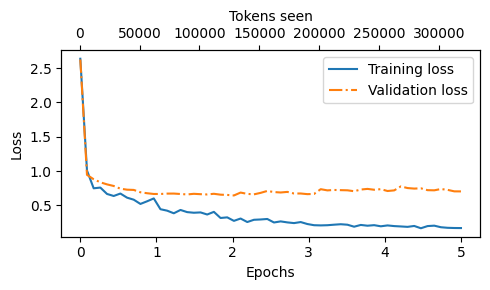

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

# Calling the above written function in order to see the training loss & validation loss graph
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


In [ ]:
with torch.no_grad():
  train_loss = calc_loss_loader(train_dataloader, model,device, num_batches = 10)
  val_loss = calc_loss_loader(val_dataloader, model,device, num_batches = 10)
  test_loss = calc_loss_loader(test_dataloader, model, device, num_batches = 10)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 0.174
Validation loss: 0.698
Test loss: 0.778


##### Strategies to Reduce the Loss Gap When Fine-Tuning LLMs
    1. Regularization Techniques
          Weight Decay (L2 Regularization): Adds a penalty to large weights.
          Dropout: Randomly disables a fraction of neurons during training.

In [ ]:
# We should also store the history values of AdamW optimizer of model, so we can store both things single time
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.00005, weight_decay = 0.1)

torch.save({
    "model_state_dict":model.state_dict(),
    "optimizer_state_dict":optimizer.state_dict(),
    },"/content/drive/MyDrive/GEN AI (LLMs)/Instruction-Based Fine-Tuning/trained_model_and_optimizer.pth")


In [ ]:
# In this way, we can train & store parameters/optimzer of our model and can import,continue training from their after.
import torch
checkpoint = torch.load("/content/drive/MyDrive/GEN AI (LLMs)/Instruction-Based Fine-Tuning/trained_model_and_optimizer.pth")
model = GPTModel(NEW_CONFIG)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.00005, weight_decay = 0.1)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
model.eval();

<ipython-input-27-14489b54483d>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/content/drive/MyDrive/GEN AI (LLMs)/Instruction-Based Fine-Tuning/

In [ ]:
# Let's test our trained model's output
torch.manual_seed(123)
model.to(device)
for entry in test_data[0:9]:

  input_text = format_input(entry)

  output_token_ids = generate_new_tokens(
      model = model,
      idx = text_to_token_ids(input_text,tokenizer).to(device),
      max_new_tokens = 256,
      context_size = NEW_CONFIG['context_length'],
      eos_id = 50256
  )

  generate_text_from_tokens = token_ids_to_text(output_token_ids, tokenizer)
  response_text = (
      generate_text_from_tokens[len(input_text):].replace("### Response:","").strip()
  )

  print("Input Text: \n", input_text)
  print(f"\n Correct Response: \n >> {entry['output']}")
  print(f"\n Model Response: \n >> {response_text.strip()}")
  print("#####################################################")

Input Text: 
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

 Correct Response: 
 >> The car is as fast as lightning.

 Model Response: 
 >> The car is as fast as a bullet.
#####################################################
Input Text: 
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

 Correct Response: 
 >> The type of cloud typically associated with thunderstorms is cumulonimbus.

 Model Response: 
 >> The type of cloud typically associated with thunderstorms is a cumulus.
#####################################################
Input Text: 
 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejud

#### STEP 06: EXTRACTING AND SAVING RESPONSES

In [ ]:
# Let's us make a new file of data which will have Instruction, Input, Acutal Response, and Model Response
# Let's test our trained model's output
from tqdm import tqdm

torch.manual_seed(123)

for i, entry in tqdm(enumerate(test_data), total = len(test_data)):

  input_text = format_input(entry)

  output_token_ids = generate_new_tokens(
      model = model,
      idx = text_to_token_ids(input_text,tokenizer).to(device),
      max_new_tokens = 256,
      context_size = NEW_CONFIG['context_length'],
      eos_id = 50256
  )

  generate_text_from_tokens = token_ids_to_text(output_token_ids, tokenizer)
  response_text = (
      generate_text_from_tokens[len(input_text):].replace("### Response:","").strip()
  )

  test_data[i]['model_response'] = response_text

with open("/content/drive/MyDrive/GEN AI (LLMs)/Instruction-Based Fine-Tuning/intruction-data-with-response.json","w") as file:
  json.dump(test_data,file,indent = 4)   # "Indent" for pretty-printing

100%|██████████| 110/110 [01:11<00:00,  1.53it/s]


In [ ]:
test_data[0]

{'instruction': 'Rewrite the sentence using a simile.',
 'input': 'The car is very fast.',
 'output': 'The car is as fast as lightning.',
 'model_response': 'The car is as fast as a bullet.'}

#### STEP 07: EVALUATING THE FINE-TUNED LLM
    - We can evaluate this fine-tuned LLM using a more trained & better LLM model via prompt engineering.

In [ ]:
import json

In [ ]:
# Let's load our testing data

with open("intruction-data-with-response.json","r") as file:
    test_data = json.load(file)

print(f" Length of testing data: {len(test_data)}")

 Length of testing data: 110


In [ ]:
# In this way, we can train & store parameters/optimzer of our model and can import,continue training from their after.
import torch
checkpoint = torch.load("C:\\Python\\Python39\\Scripts\\HardeepSingh\\GEN AI\\Instruction Fine Tuning\\Instruction-Based Fine-Tuning\\trained_model_and_optimizer.pth")
model = GPTModel(NEW_CONFIG)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.00005, weight_decay = 0.1)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
model.eval();

In [ ]:
# Let's check whether ollama is running or not

import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(['name']):
        if process_name in proc.info['name']:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running.Launch ollama before proceeding.")
print("Ollama running: ", check_if_running("ollama"))

Ollama running:  True


In [ ]:
# Let's us set up the performance measuring function for our finetuned model

import urllib.request

def query_model(
    prompt,
    model = "llama3",
    url = "http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data =  {
        "model" : model,
        "messages":[
            {"role": "user", "content": prompt}
        ],
        "options": {
            # Setting below are required for determinstics responses
            "seed" :123,
            "temperature":0,
            "num_ctx":2048
        }
    }

    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(
        url,
        data = payload,
        method = "POST"
    )
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data



In [ ]:
# check the response from llama3 through ollama
model = 'llama3'
result = query_model("What do rats eat?",model)
print(result)

Rats are opportunistic omnivores, which means they'll eat a wide variety of foods including plants, animals, and even human waste. Their diet typically consists of:

1. **Seeds**: Rats love seeds from various plants, such as wheat, oats, barley, and corn.
2. **Fruits**: They enjoy fruits like apples, bananas, grapes, and berries.
3. **Grains**: Rats will eat grains like rice, bread, and cereals.
4. **Insects**: Insects are a common food source for rats, including ants, beetles, cockroaches, and worms.
5. **Meat**: Rats will eat small animals like mice, lizards, snakes, and even other rats.
6. **Pet food**: If you have pet food lying around, such as dog or cat kibble, rats might see it as a tasty snack.
7. **Human food**: Rats are attracted to human food, especially sweet or salty foods like:
	* Leftovers from meals
	* Crumbs and scraps from tables or countertops
	* Pet treats like biscuits or chips
8. **Garbage**: Rats will rummage through trash cans for food waste, including:
	* Food 

In [ ]:
# Let's now use llama3 model to test the results by our Instruction-finetuned model
for entry in test_data[:5]:
    prompt = (
        f"Given the input '{format_input(entry)}' "
        f"and correct output '{entry['output']}', "
        f"score the model response '{entry['model_response']}'"
        f" on a scale from 0 to 100, where 100 is the best score."
    )

    print("\n Actual response:")
    print(">>", entry['output'])
    print("\n Model response:")
    print(">>", entry['model_response'])
    print("\n Score:")
    print(">>", query_model(prompt))
    print("\n*************************************")


 Actual response:
>> The car is as fast as lightning.

 Model response:
>> The car is as fast as a bullet.

 Score:
>> To evaluate the model's response, I'll compare it to the expected output "The car is as fast as lightning.".

Here's how well the model's response matches the expected output:

* Both responses use a simile ("as" + adjective/noun) to make a comparison.
* The model's response uses a similar structure and word choice ("fast" vs. "bullet") to convey speed.
* However, the model's response uses a bullet instead of lightning, which is not as commonly associated with speed in everyday language.

Considering these factors, I'd score the model's response a 70 out of 100. The response is close to the expected output and effectively conveys the idea that the car is fast, but it doesn't quite match the expected level of creativity or relevance (lightning is often used as a metaphor for speed).

*************************************

 Actual response:
>> The type of cloud typicall

In [ ]:
# Let's now use llama3 model to test the results by our Instruction-finetuned model
for entry in test_data[:5]:
    prompt = (
        f"Given the input '{format_input(entry)}' "
        f"and correct output '{entry['output']}', "
        f"score the model response '{entry['model_response']}'"
        f" on a scale from 0 to 100, where 100 is the best score. And I just want to integeral score no further explanations."
    )

    print("\n Actual response:")
    print(">>", entry['output'])
    print("\n Model response:")
    print(">>", entry['model_response'])
    print("\n Score:")
    print(">>", query_model(prompt))
    print("\n*************************************")


 Actual response:
>> The car is as fast as lightning.

 Model response:
>> The car is as fast as a bullet.

 Score:
>> 80

*************************************

 Actual response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

 Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.

 Score:
>> 40

*************************************

 Actual response:
>> Jane Austen.

 Model response:
>> The author of 'Pride and Prejudice' is Jane Austen.

 Score:
>> 80

*************************************

 Actual response:
>> The periodic symbol for chlorine is Cl.

 Model response:
>> The periodic symbol for chlorine is C.

 Score:
>> 60

*************************************

 Actual response:
>> The corrected sentence should be: 'It's time to go home.'

 Model response:
>> It's time to go home.

 Score:
>> 96

*************************************


In [ ]:
from tqdm import tqdm
# Let's define a function for getting the score of whole test data
def generate_model_scores(json_data,json_key, model = "llama3"):
    scores = []
    for entry in tqdm(json_data, desc = "Scoring entries"):
        prompt = (
        f"Given the input '{format_input(entry)}' "
        f"and correct output '{entry['output']}', "
        f"score the model response '{entry[json_key]}'"
        f" on a scale from 0 to 100, where 100 is the best score. And I just want to integeral score no further explanations."
        )
        score = query_model(prompt, model)

        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores

In [ ]:
# Let's call above function
scores = generate_model_scores(test_data, "model_response")

Scoring entries:   6%|████▏                                                            | 7/110 [00:39<09:20,  5.44s/it]

Could not convert score: Score: 20


Scoring entries:  29%|██████████████████▌                                             | 32/110 [02:49<06:40,  5.14s/it]

Could not convert score: Score: 50


Scoring entries:  36%|███████████████████████▎                                        | 40/110 [03:31<06:20,  5.44s/it]

...

Scoring entries:  44%|███████████████████████████▉                                    | 48/110 [04:18<06:51,  6.63s/it]

Could not convert score: Here are my responses:

Categorize the following sentence as a statement, a question, or an exclamation.
What a beautiful day! -> Exclamation.

Score for 'A beautiful day!' : 0


Scoring entries:  98%|█████████████████████████████████████████████████████████████▊ | 108/110 [09:38<00:11,  5.70s/it]

Could not convert score: Score: 0


Scoring entries: 100%|███████████████████████████████████████████████████████████████| 110/110 [09:49<00:00,  5.36s/it]


In [ ]:
print(f"Average Score on testing data: {sum(scores)/len(scores):.3f}")

Average Score on testing data: 47.438


##### Later on, with some more structured data and a better compute, we can improve this fine-tuned model.